# **Importing Dataset**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("rishabhzen/helmet-detection")

Using Colab cache for faster access to the 'helmet-detection' dataset.


# **Importing Libraries**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

Creating variables and assigning paths to them

In [ ]:
helmet_path = "/kaggle/input/helmet-detection/helmet_dataset/train/helmet"
nohelmet_path = "/kaggle/input/helmet-detection/helmet_dataset/train/no helmet"

# **Image Preprocessing**

Now we do image preprocessing on each image before training so it that is
make easir to Deep learning model to dectect edges also we have alot of images we pass it number of bulk or batches  so that process make faster
and also devide the dataset for training and validation then we apply data_augmentation for apply rotation and fliping.

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/helmet-detection/helmet_dataset/train/",
    image_size=(224, 224),
    batch_size=32,
    label_mode ='binary',
    subset="training",
    validation_split=0.2,
    seed=42

)

val_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/helmet-detection/helmet_dataset/train/",
    image_size=(224, 224),
    batch_size=32,
    label_mode ='binary',
    subset="validation",
    validation_split=0.2,
    seed=42
)


data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(height_factor=0.2),
])

Found 1200 files belonging to 2 classes.
Using 960 files for training.
Found 1200 files belonging to 2 classes.
Using 240 files for validation.


# **Training on CNN**

Now after preprocessing its time to tain the model. AS we know for images we CNN and CNN require large amount of images data for better accuracy  but we have small no of images data set so we use MObileNetV3Large a pretrianed architeture of CNN that is already tarain on images so we got boost in accuracy and it also decreases the over fitting and under fitting so firstly we make CNN layers then we complie the CNN model and then we start the tarining.

In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = MobileNetV3Large(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

cnn = Sequential([
    layers.Input(shape=(224, 224, 3)),
    # layers.Lambda(preprocess_input),   # ONLY this -- no Rescaling layer, ever, alongside this
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

In [ ]:
base_model.trainable = True

# Only unfreeze the top ~30 layers, keep the early generic-feature layers frozen
fine_tune_at = len(base_model.layers) - 60
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
cnn.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,489 (11.90 MB)

 Trainable params: 2,612,113 (9.96 MB)

 Non-trainable params: 507,376 (1.94 MB)

In [ ]:
history = cnn.fit(train_ds,epochs=20,batch_size=32,validation_data=(val_ds),verbose=1,
                   callbacks=[ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.7948 - loss: 0.4362 - val_accuracy: 0.8417 - val_loss: 0.8294 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.9167 - loss: 0.1884 - val_accuracy: 0.8167 - val_loss: 1.5829 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.9479 - loss: 0.1293 - val_accuracy: 0.7875 - val_loss: 1.9482 - learning_rate: 0.0010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.9729 - loss: 0.0894 - val_accuracy: 0.8542 - val_loss: 1.1372 - learning_rate: 0.0010
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.9750 - loss: 0.0659 - val_accuracy: 0.8750 - val_loss: 0.9328 - learning_rate: 5.0000e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9865 - loss: 0.0457 - val_accuracy: 0.9125 - val_loss: 0.5766 - learning_rate: 5.0000e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.9937 - loss: 

# **Drawing graphs**
Now we Draw graphs to see Accuracy on Epchoes and Loss on Epchopes

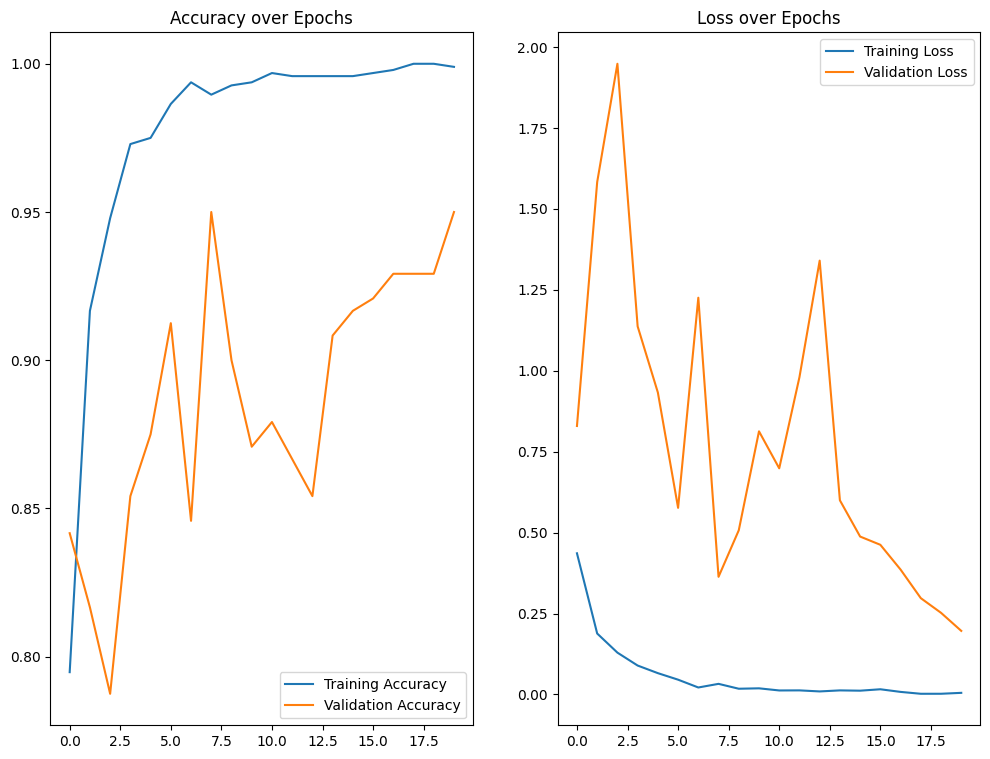

Final Validation Accuracy: 95.00%


In [ ]:
acc = history.history["accuracy"]
loss = history.history["loss"]
val_acc =history.history["val_accuracy"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12,9))
plt.subplot(1,2,1)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.show()

final_val_acc = val_acc[-1] * 100
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")


In [ ]:
cnn.save("Helemt_prediction.keras")

# **Checking prediections**

Here we check the model predictions is it guess right or wrong

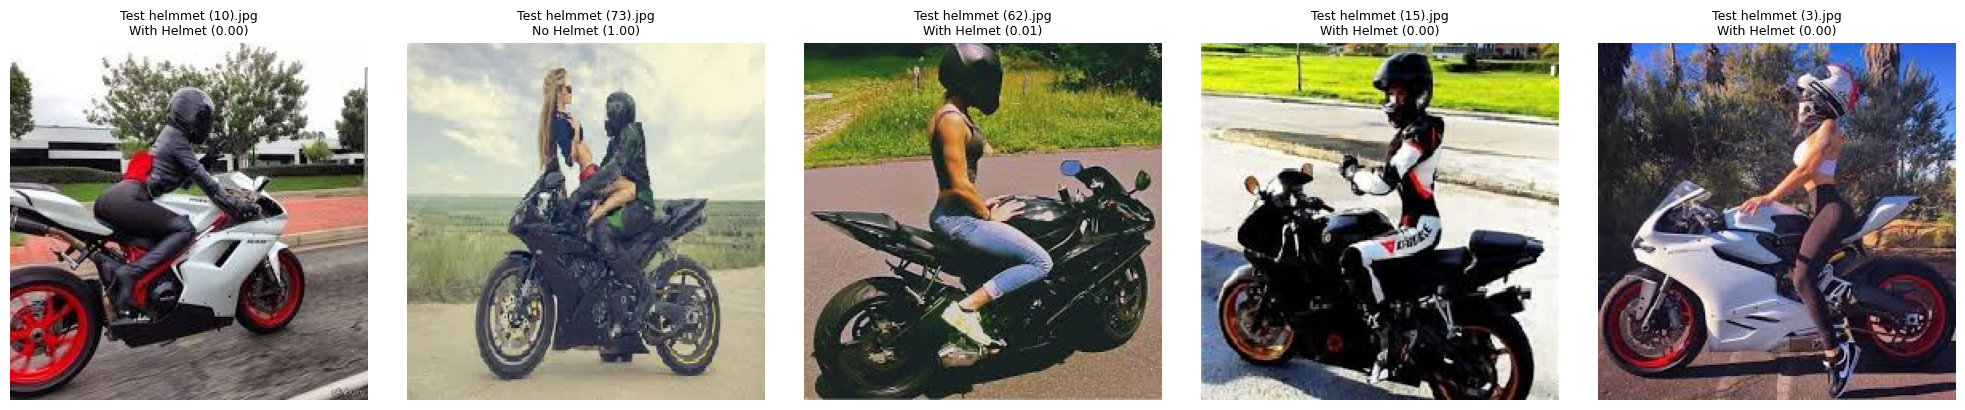

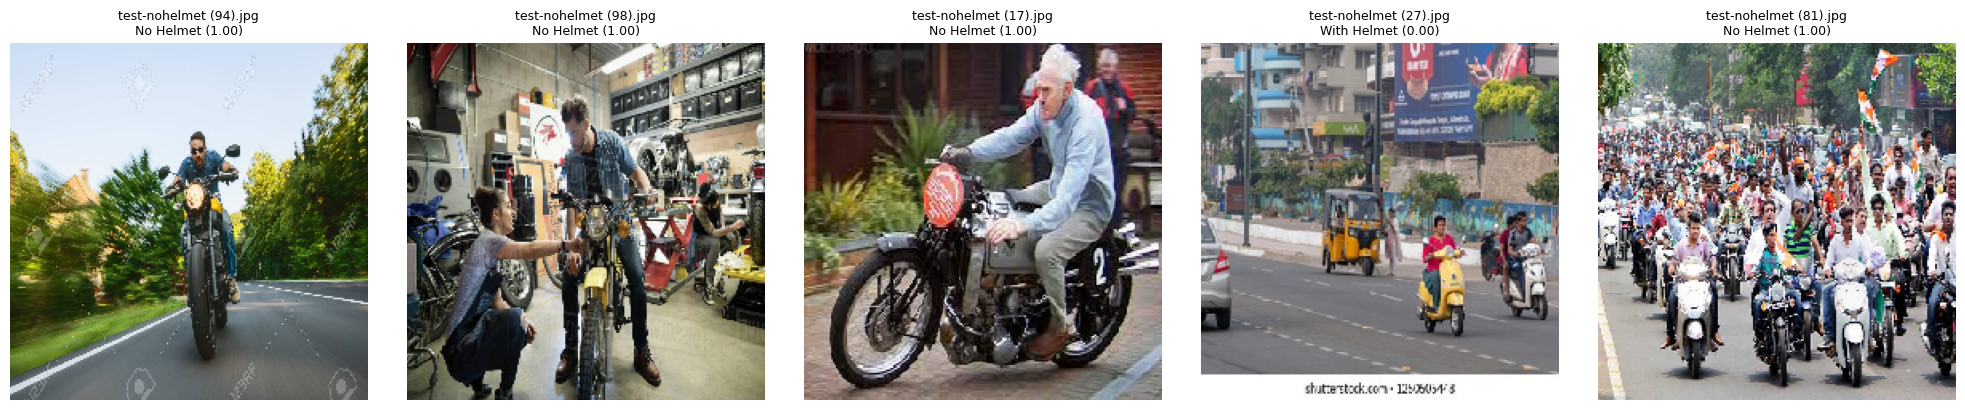

In [ ]:
import random
from tensorflow.keras.preprocessing import image as keras_image
def predict_random_images(folder_path, n=5, cols=5):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    sample_files = random.sample(files, min(n, len(files)))   # avoids error if folder has < n images

    fig, axes = plt.subplots(1, len(sample_files), figsize=(4*len(sample_files), 4))
    if len(sample_files) == 1:
        axes = [axes]   # keep it iterable even for a single image

    for ax, filename in zip(axes, sample_files):
        img_path = os.path.join(folder_path, filename)
        img = keras_image.load_img(img_path, target_size=(224, 224))
        img_array = np.expand_dims(keras_image.img_to_array(img), axis=0)
        score = cnn.predict(img_array, verbose=0)[0][0]
        pred_label = "With Helmet" if score < 0.5 else "No Helmet"

        ax.imshow(img)
        ax.set_title(f"{filename}\n{pred_label} ({score:.2f})", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

predict_random_images("/kaggle/input/helmet-detection/helmet_dataset/test/helmet",n=5)
predict_random_images("/kaggle/input/helmet-detection/helmet_dataset/test/no_helmet",n=5)